# CS-13410 Introduction to Machine Learning — Semester Project
## Part 1: Problem Framing, Exploratory Analysis & Leakage-Free Pipeline

### 1. Problem Framing
* **Dataset Name:** Telco Customer Churn (IBM / Kaggle)
* **Problem Statement:** A telecommunications provider faces customer attrition. Retaining existing customers costs significantly less than acquiring new ones. The business goal is to proactively identify customers at risk of canceling their subscriptions so that retention teams can intervene.
* **Prediction Target:** `Churn` — A binary categorical target indicating whether the customer left within the last month (`Yes` = 1, `No` = 0).
* **Task Type:** Binary Classification.
* **Primary Success Metrics:** 
  * **ROC-AUC & PR-AUC:** The target distribution is imbalanced (~73.4% non-churn vs. 26.6% churn). Raw accuracy produces overly optimistic evaluations; area under ROC and PR curves measures true discriminative capability across all decision thresholds.
  * **F1-Score (Minority / Churn Class):** Harmonizes precision (avoiding unnecessary retention promotions) and recall (catching as many leaving customers as possible).

### 2. Dataset Justification
* **Scale:** Contains 7,043 samples and 21 columns, satisfying the minimum >1,000 row requirement.
* **Feature Diversity:** Combines demographic variables (`gender`, `SeniorCitizen`), account/billing features (`tenure`, `Contract`, `MonthlyCharges`), and subscribed service indicators (`InternetService`, `TechSupport`).
* **Technical Suitability:** Contains missing/inconsistent values (`TotalCharges`), categorical nominal features requiring one-hot encoding, and continuous features requiring scaling. It cleanly supports Part 1's leakage-free pipeline, Part 2's tree splits, Part 3's gradient boosting, and Part 4's neural networks and customer segmentation.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Set plot style
sns.set_theme(style="whitegrid")

# 1. Load raw data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Drop irrelevant identifier (customerID contains no predictive signal)
df = df.drop(columns=["customerID"])

# 3. Handle inconsistent whitespace strings in TotalCharges and coerce to float
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")

# 4. Remove duplicate rows if any
df = df.drop_duplicates()

# 5. Encode binary target: 1 = Yes (Churned), 0 = No (Retained)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Shape after raw cleaning:", df.shape)
print("Target Distribution:\n", df["Churn"].value_counts(normalize=True) * 100)

Shape after raw cleaning: (7021, 20)
Target Distribution:
 Churn
0    73.550776
1    26.449224
Name: proportion, dtype: float64


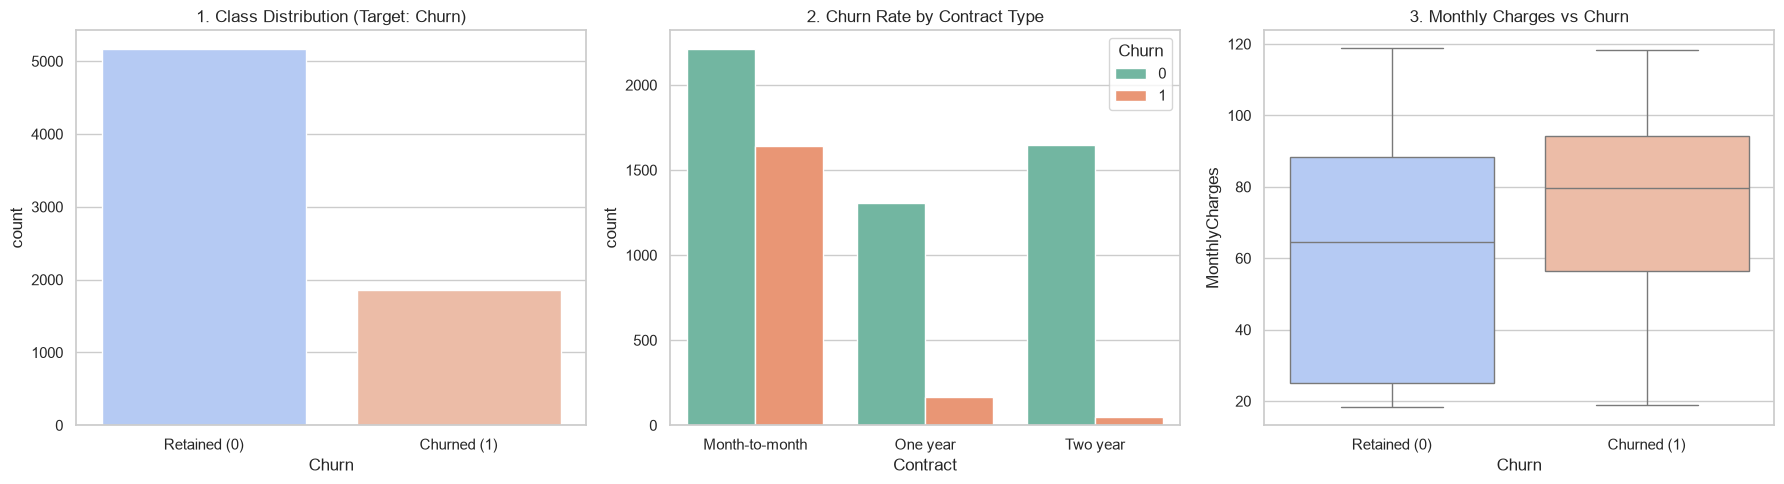

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target Variable Imbalance
sns.countplot(x="Churn", hue="Churn", data=df, ax=axes[0], palette="coolwarm", legend=False)
axes[0].set_title("1. Class Distribution (Target: Churn)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Retained (0)", "Churned (1)"])

# Plot 2: Churn by Contract Type (Categorical vs Target)
sns.countplot(x="Contract", hue="Churn", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("2. Churn Rate by Contract Type")

# Plot 3: Monthly Charges vs Churn (Numerical vs Target)
sns.boxplot(x="Churn", y="MonthlyCharges", hue="Churn", data=df, ax=axes[2], palette="coolwarm", legend=False)
axes[2].set_title("3. Monthly Charges vs Churn")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Retained (0)", "Churned (1)"])

plt.tight_layout()
plt.show()

In [14]:
# 1. Separate features (X) and target (y)
X = df.drop(columns=["Churn"])
y = df["Churn"]

# 2. Train-Test Split with stratification to preserve the ~73/27 class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing set:  X_test  = {X_test.shape}, y_test  = {y_test.shape}")

Training set: X_train = (5616, 19), y_train = (5616,)
Testing set:  X_test  = (1405, 19), y_test  = (1405,)


In [15]:
# 1. Define feature subsets
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [col for col in X.columns if col not in numeric_features]

# 2. Pipeline for numeric columns: impute missing values (median) + scale
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 3. Pipeline for categorical columns: impute if missing + One-Hot Encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# 4. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# 5. Fit ONLY on training data, then transform both train and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 6. Extract clean feature names for verification
encoded_cat_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

print("Pipeline execution successful!")
print(f"Final Processed Training Shape: {X_train_processed.shape}")
print(f"Final Processed Testing Shape:  {X_test_processed.shape}")
print(f"Total Features After One-Hot Encoding: {len(all_feature_names)}")

Pipeline execution successful!
Final Processed Training Shape: (5616, 30)
Final Processed Testing Shape:  (1405, 30)
Total Features After One-Hot Encoding: 30


In [16]:
# Verify dataset is completely ready for ML models
print("Any NaNs in X_train_processed?", np.isnan(X_train_processed).sum())
print("Any NaNs in X_test_processed?", np.isnan(X_test_processed).sum())
print("All values finite?", np.all(np.isfinite(X_train_processed)) and np.all(np.isfinite(X_test_processed)))

Any NaNs in X_train_processed? 0
Any NaNs in X_test_processed? 0
All values finite? True
